# Hotel Booking Analysis
**Goal**: Analyze hotel bookings and predict cancellations

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('hotel_bookings.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## 2. Data Cleaning

In [3]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values:
children         4
country        488
agent        16340
company     112593
dtype: int64


In [4]:
if 'children' in df.columns:
    df['children'] = df['children'].fillna(0)

if 'country' in df.columns:
    df['country'] = df['country'].fillna('Unknown')

if 'agent' in df.columns:
    df['agent'] = df['agent'].fillna(0)

if 'company' in df.columns:
    df['company'] = df['company'].fillna(0)
df.drop_duplicates(inplace=True)

pii_cols = ['name', 'email', 'phone-number', 'credit_card']
df.drop(columns=pii_cols, inplace=True, errors='ignore')

print("Data Cleaning Completed Successfully!")
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

df.head()

Data Cleaning Completed Successfully!
Dataset Shape: (87396, 32)

Missing Values After Cleaning:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
day

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 3. Feature Engineering

In [5]:
df['Total_Guests'] = df['adults'] + df['children'] + df['babies']
df['Stay_Duration'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

df = df[df['adr'] >= 0]
df = df[df['Total_Guests'] > 0]

print(f"Total_Guests range: {df['Total_Guests'].min()} - {df['Total_Guests'].max()}")
print(f"Stay_Duration range: {df['Stay_Duration'].min()} - {df['Stay_Duration'].max()}")

Total_Guests range: 1.0 - 55.0
Stay_Duration range: 0 - 69


## 4. Outlier Handling

In [6]:
for col in ['adr', 'Total_Guests', 'Stay_Duration']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

adr: 2508 outliers (2.9%)
Total_Guests: 30173 outliers (34.6%)
Stay_Duration: 2990 outliers (3.4%)


In [7]:
for col in ['adr', 'Stay_Duration']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    print(f"{col} clipped to [{Q1-1.5*IQR:.1f}, {Q3+1.5*IQR:.1f}]")

df['Guest_Group'] = pd.cut(df['Total_Guests'],
                           bins=[0,1,2,3,4,999],
                           labels=['1','2','3','4','5+'])

print("Outlier handling done!")

adr clipped to [-20.5, 226.9]
Stay_Duration clipped to [-2.5, 9.5]
Outlier handling done!


## 5. Exploratory Data Analysis (EDA)

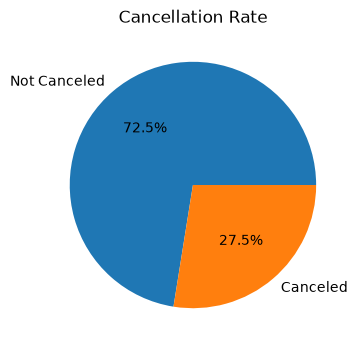

In [8]:
plt.figure(figsize=(6,4))
df['is_canceled'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                       labels=['Not Canceled','Canceled'])
plt.title('Cancellation Rate')
plt.ylabel('')
plt.show()

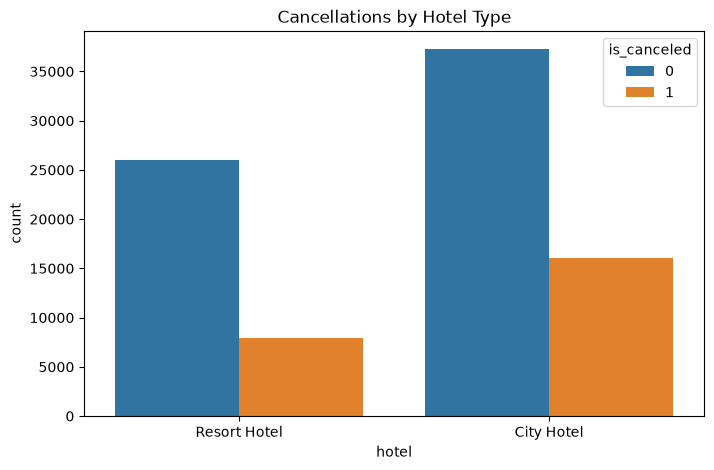

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title('Cancellations by Hotel Type')
plt.show()

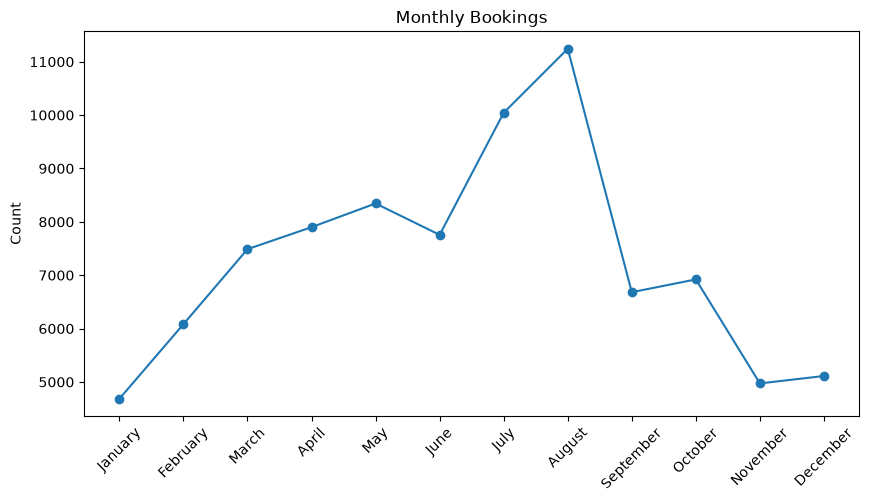

In [10]:
months = ['January','February','March','April','May','June',
          'July','August','September','October','November','December']
monthly = df['arrival_date_month'].value_counts().reindex(months)

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title('Monthly Bookings')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

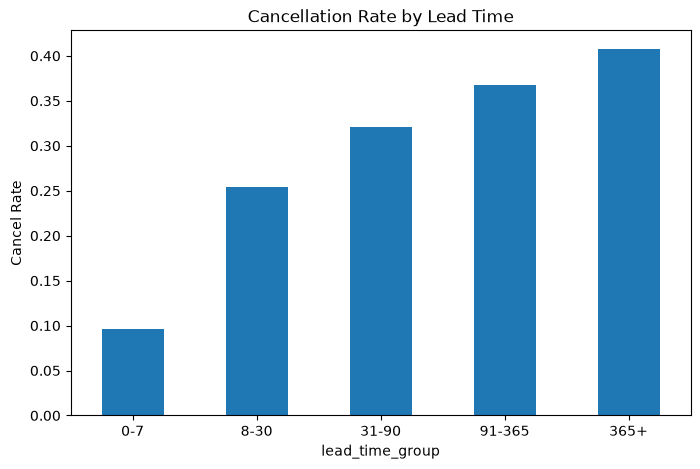

In [11]:
df['lead_time_group'] = pd.cut(df['lead_time'],
                               bins=[0,7,30,90,365,999],
                               labels=['0-7','8-30','31-90','91-365','365+'])

plt.figure(figsize=(8,5))
cancel_rate = df.groupby('lead_time_group')['is_canceled'].mean()
cancel_rate.plot(kind='bar')
plt.title('Cancellation Rate by Lead Time')
plt.ylabel('Cancel Rate')
plt.xticks(rotation=0)
plt.show()

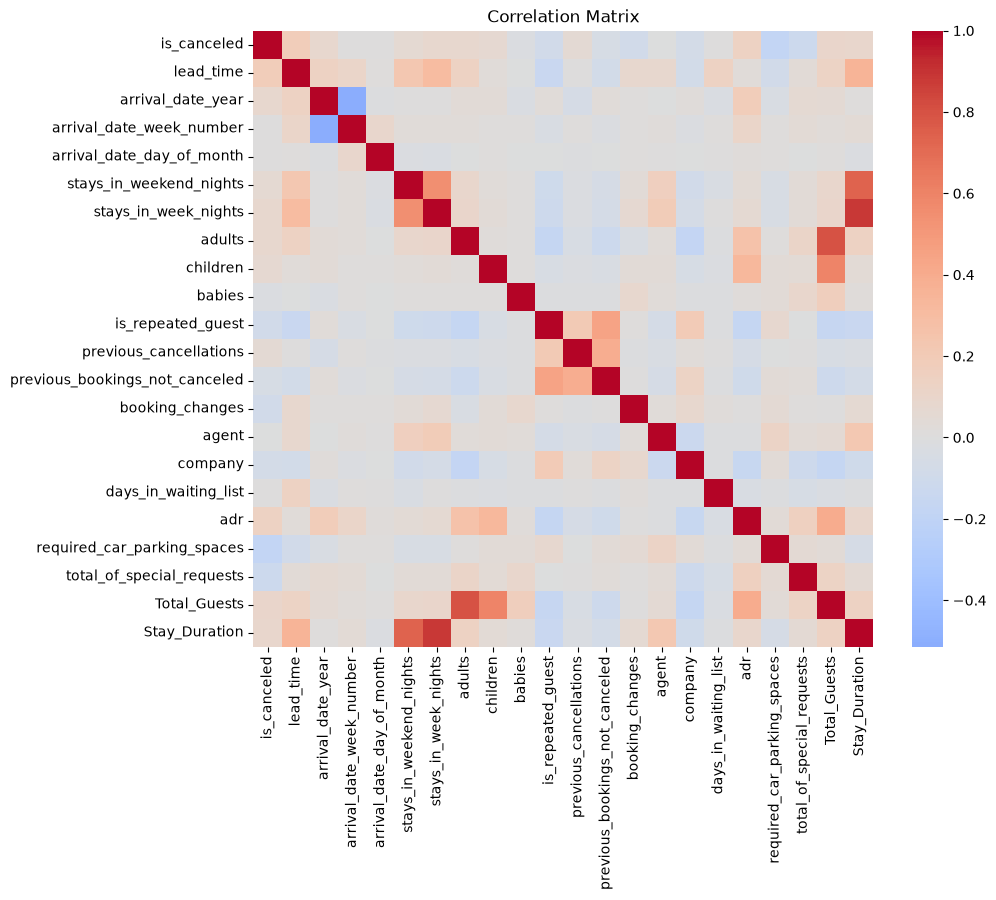

In [12]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

### 5.1 Creative EDA: Business Insights

In [13]:
cancelled = df[df['is_canceled'] == 1]
not_cancelled = df[df['is_canceled'] == 0]

lost_revenue = cancelled['adr'].sum() * cancelled['Stay_Duration'].mean()
actual_revenue = not_cancelled['adr'].sum() * not_cancelled['Stay_Duration'].mean()

print("💰 REVENUE ANALYSIS")
print(f"Potential Lost Revenue: ${lost_revenue:,.0f}")
print(f"Actual Revenue: ${actual_revenue:,.0f}")
print(f"Loss Percentage: {lost_revenue/(lost_revenue+actual_revenue)*100:.1f}%")

💰 REVENUE ANALYSIS
Potential Lost Revenue: $10,743,521
Actual Revenue: $21,682,658
Loss Percentage: 33.1%


In [14]:
segment_analysis = df.groupby('market_segment').agg({
    'is_canceled': 'mean',
    'adr': 'mean',
    'hotel': 'count'
}).rename(columns={'is_canceled': 'cancel_rate', 'adr': 'avg_price', 'hotel': 'bookings'})

segment_analysis['risk_score'] = segment_analysis['cancel_rate'] * 100
segment_analysis['value_score'] = segment_analysis['avg_price'] * (1 - segment_analysis['cancel_rate'])

print("📊 CUSTOMER SEGMENT ANALYSIS")
print(segment_analysis.round(2))

📊 CUSTOMER SEGMENT ANALYSIS
                cancel_rate  avg_price  bookings  risk_score  value_score
market_segment                                                           
Aviation               0.20     100.61       226       19.91        80.58
Complementary          0.12       3.09       692       12.28         2.71
Corporate              0.12      68.24      4200       12.12        59.97
Direct                 0.15     114.78     11780       14.75        97.85
Groups                 0.27      74.84      4921       27.07        54.59
Offline TA/TO          0.15      81.44     13855       14.85        69.35
Online TA              0.35     117.24     51553       35.38        75.76
Undefined              1.00      15.00         2      100.00         0.00


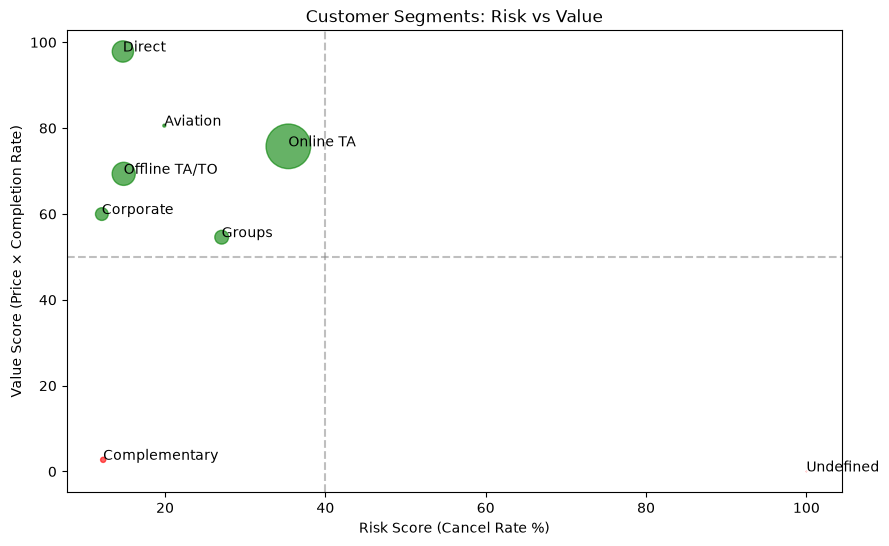

🎯 Top Right = Low Risk, High Value | Bottom Left = High Risk, Low Value


In [15]:
fig, ax = plt.subplots(figsize=(10,6))
colors = ['green' if v > 50 else 'red' for v in segment_analysis['value_score']]
ax.scatter(segment_analysis['risk_score'], segment_analysis['value_score'],
           s=segment_analysis['bookings']/50, c=colors, alpha=0.6)

for i, seg in enumerate(segment_analysis.index):
    ax.annotate(seg, (segment_analysis['risk_score'].iloc[i],
                      segment_analysis['value_score'].iloc[i]))

ax.set_xlabel('Risk Score (Cancel Rate %)')
ax.set_ylabel('Value Score (Price × Completion Rate)')
ax.set_title('Customer Segments: Risk vs Value')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=40, color='gray', linestyle='--', alpha=0.5)
plt.show()
print("🎯 Top Right = Low Risk, High Value | Bottom Left = High Risk, Low Value")

🔑 DEPOSIT TYPE IMPACT (Key Business Insight!)
              cancel_rate  count  avg_price
deposit_type                               
No Deposit          0.267  86084    105.773
Non Refund          0.947   1038     87.243
Refundable          0.243    107     79.879

⚠️ Non-refundable deposits have HIGHEST cancellation - counterintuitive!


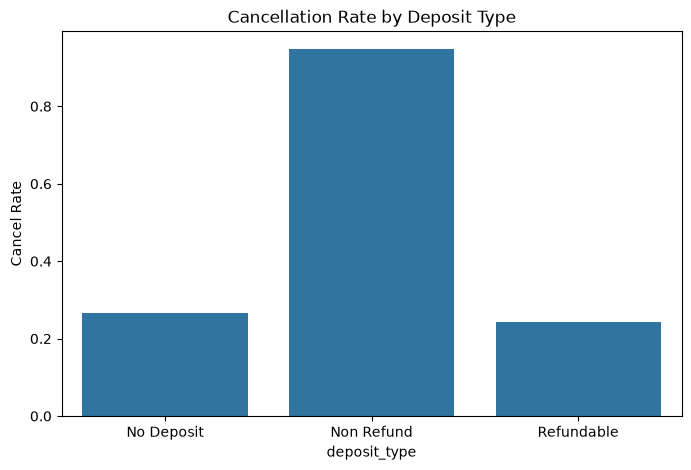

In [16]:
deposit_impact = df.groupby('deposit_type').agg({
    'is_canceled': ['mean', 'count'],
    'adr': 'mean'
}).round(3)
deposit_impact.columns = ['cancel_rate', 'count', 'avg_price']

print("🔑 DEPOSIT TYPE IMPACT (Key Business Insight!)")
print(deposit_impact)
print("\n⚠️ Non-refundable deposits have HIGHEST cancellation - counterintuitive!")
plt.figure(figsize=(8,5))
sns.barplot(x=deposit_impact.index, y=deposit_impact['cancel_rate'])
plt.title('Cancellation Rate by Deposit Type')
plt.ylabel('Cancel Rate')
plt.show()

In [17]:
df['booking_type'] = np.where(df['stays_in_weekend_nights'] > df['stays_in_week_nights'],
                               'Weekend Heavy', 'Weekday Heavy')
booking_pattern = df.groupby('booking_type').agg({
    'is_canceled': 'mean',
    'adr': 'mean'
}).round(3)

print("📅 WEEKEND vs WEEKDAY BOOKINGS")
print(booking_pattern)

📅 WEEKEND vs WEEKDAY BOOKINGS
               is_canceled      adr
booking_type                       
Weekday Heavy        0.279  105.818
Weekend Heavy        0.244  103.208


## 6. Prepare Data for Modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

drop_cols = ['reservation_status', 'reservation_status_date', 'lead_time_group']
df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)

cat_cols = df_model.select_dtypes(include=['object','category']).columns
for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 69783, Test: 17446


## 7. Feature Importance

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Important Features:")
print(importance.head(10))

Top 10 Important Features:
                        feature  importance
1                     lead_time    0.145478
13               market_segment    0.125797
12                      country    0.116035
28    total_of_special_requests    0.108375
27  required_car_parking_spaces    0.084697
22                        agent    0.069953
21                 deposit_type    0.054156
16       previous_cancellations    0.042505
25                customer_type    0.035714
26                          adr    0.030188


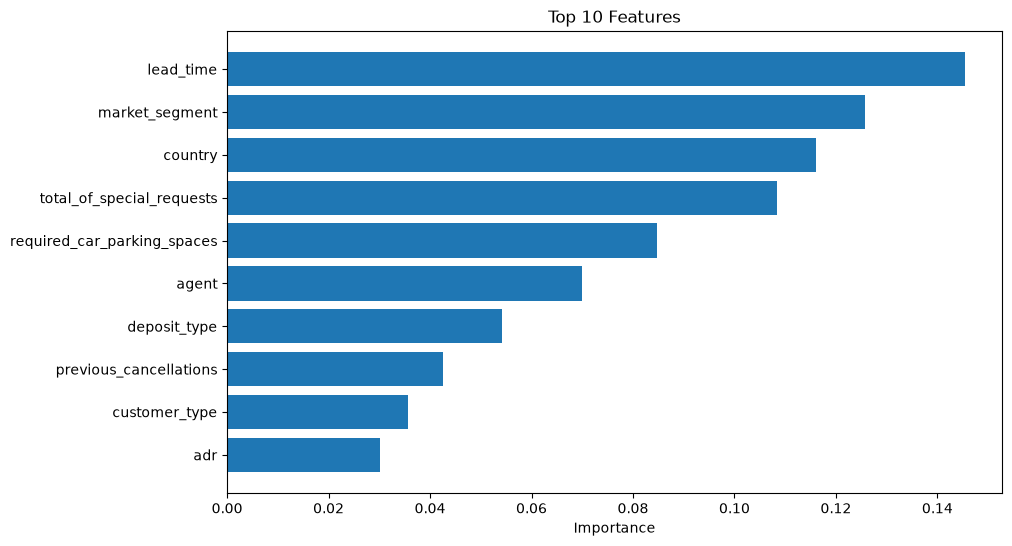

In [20]:
plt.figure(figsize=(10,6))
top10 = importance.head(10)
plt.barh(top10['feature'], top10['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features')
plt.gca().invert_yaxis()
plt.show()

## 8. Model Comparison

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

top_features = importance.head(10)['feature'].tolist()

dt_all = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_all.fit(X_train, y_train)
acc_all = accuracy_score(y_test, dt_all.predict(X_test))

dt_top = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_top.fit(X_train[top_features], y_train)
acc_top = accuracy_score(y_test, dt_top.predict(X_test[top_features]))

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train[top_features], y_train)
acc_lr = accuracy_score(y_test, lr.predict(X_test[top_features]))

print("Model Comparison:")
print(f"  Decision Tree (all features):  {acc_all:.4f}")
print(f"  Decision Tree (top features):  {acc_top:.4f}")
print(f"  Logistic Regression:           {acc_lr:.4f}")

Model Comparison:
  Decision Tree (all features):  0.8148
  Decision Tree (top features):  0.8161
  Logistic Regression:           0.7637


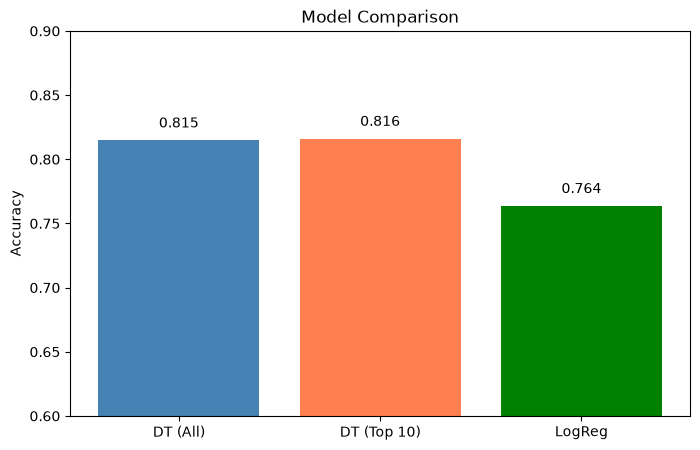

In [22]:
models = ['DT (All)', 'DT (Top 10)', 'LogReg']
scores = [acc_all, acc_top, acc_lr]

plt.figure(figsize=(8,5))
plt.bar(models, scores, color=['steelblue','coral','green'])
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0.6, 0.9)
for i, v in enumerate(scores):
    plt.text(i, v+0.01, f'{v:.3f}', ha='center')
plt.show()

## 9. PCA Analysis

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features: {X_train.shape[1]}")
print(f"PCA features: {X_train_pca.shape[1]}")
print(f"Variance retained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

Original features: 33
PCA features: 25
Variance retained: 96.3%


In [24]:
dt_pca = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, dt_pca.predict(X_test_pca))

print(f"Decision Tree with PCA: {acc_pca:.4f}")
print(f"Compared to all features: {acc_all:.4f}")

Decision Tree with PCA: 0.7732
Compared to all features: 0.8148


---
## 10. Predictive Model 1: Customer Cancellation Risk

**Goal**: Predict which customers are likely to cancel based on their profile

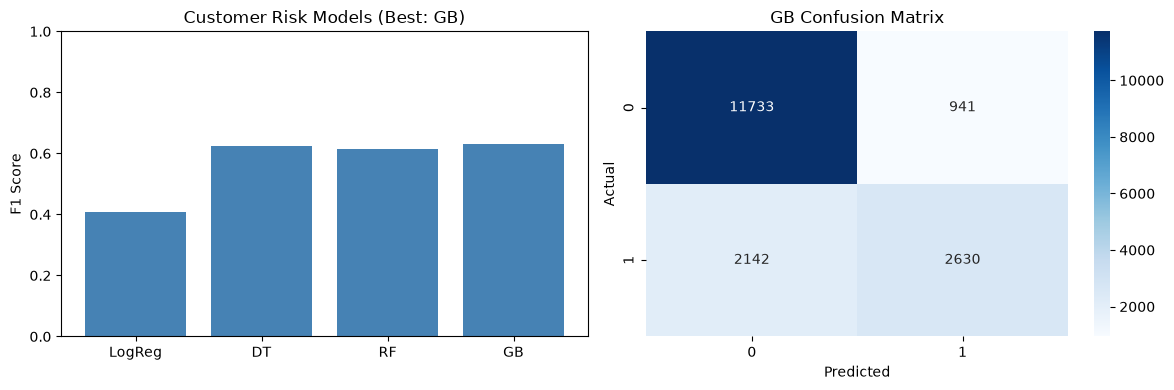

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import seaborn as sns

customer_features = importance.head(10)['feature'].tolist()
X_cust_train = X_train[customer_features]
X_cust_test = X_test[customer_features]

models = {
    'LogReg': LogisticRegression(max_iter=500, random_state=42),
    'DT': DecisionTreeClassifier(max_depth=10, random_state=42),
    'RF': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42),
    'GB': GradientBoostingClassifier(n_estimators=50, max_depth=5, random_state=42)
}

results_risk = {}
for name, model in models.items():
    model.fit(X_cust_train, y_train)
    y_pred = model.predict(X_cust_test)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    results_risk[name] = {'f1': f1, 'acc': acc, 'model': model, 'pred': y_pred}

best_risk = max(results_risk, key=lambda x: results_risk[x]['f1'])
lr_risk = results_risk[best_risk]['model']

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].bar(models.keys(), [results_risk[n]['f1'] for n in models], color='steelblue')
axes[0].set_ylabel('F1 Score')
axes[0].set_title(f'Customer Risk Models (Best: {best_risk})')
axes[0].set_ylim(0, 1)

cm = confusion_matrix(y_test, results_risk[best_risk]['pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'{best_risk} Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 11. Predictive Model 2: Room Price Prediction

**Goal**: Predict room price (ADR) based on booking characteristics

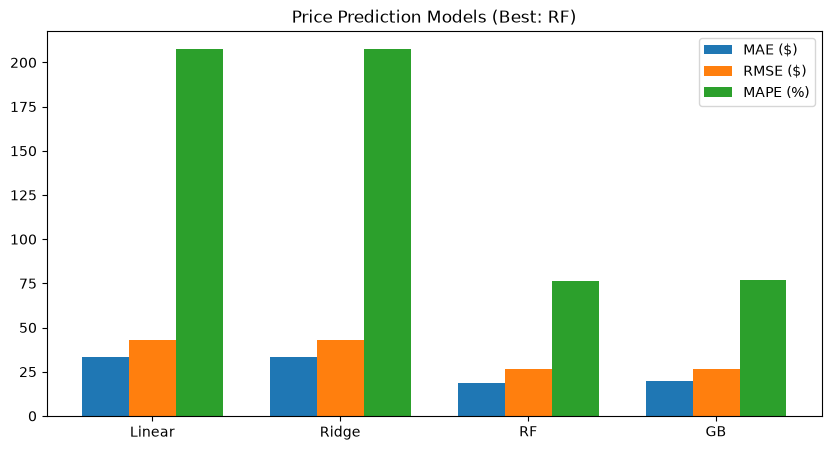

In [26]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

price_features = ['hotel', 'lead_time', 'arrival_date_month', 'Stay_Duration',
                  'Total_Guests', 'meal', 'market_segment', 'deposit_type']
price_features = [f for f in price_features if f in df_model.columns]

X_price = df_model[price_features]
y_price = df_model['adr']
X_price_train, X_price_test, y_price_train, y_price_test = train_test_split(
    X_price, y_price, test_size=0.2, random_state=42)

reg_models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=10.0),
    'RF': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
    'GB': GradientBoostingRegressor(n_estimators=50, max_depth=5, random_state=42)
}

results_price = {}
for name, model in reg_models.items():
    model.fit(X_price_train, y_price_train)
    y_pred = model.predict(X_price_test)
    mae = mean_absolute_error(y_price_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_price_test, y_pred))
    mape = np.mean(np.abs((y_price_test - y_pred) / (y_price_test + 1))) * 100
    r2 = r2_score(y_price_test, y_pred)
    results_price[name] = {'mae': mae, 'rmse': rmse, 'mape': mape, 'r2': r2, 'model': model}

best_price = min(results_price, key=lambda x: results_price[x]['mae'])
rf_price = results_price[best_price]['model']

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(reg_models))
width = 0.25
ax.bar(x - width, [results_price[n]['mae'] for n in reg_models], width, label='MAE ($)')
ax.bar(x, [results_price[n]['rmse'] for n in reg_models], width, label='RMSE ($)')
ax.bar(x + width, [results_price[n]['mape'] for n in reg_models], width, label='MAPE (%)')
ax.set_xticks(x)
ax.set_xticklabels(reg_models.keys())
ax.legend()
ax.set_title(f'Price Prediction Models (Best: {best_price})')
plt.show()

## 12. Predictive Model 3: Monthly Demand Forecasting

**Goal**: Predict how many bookings we'll get each month

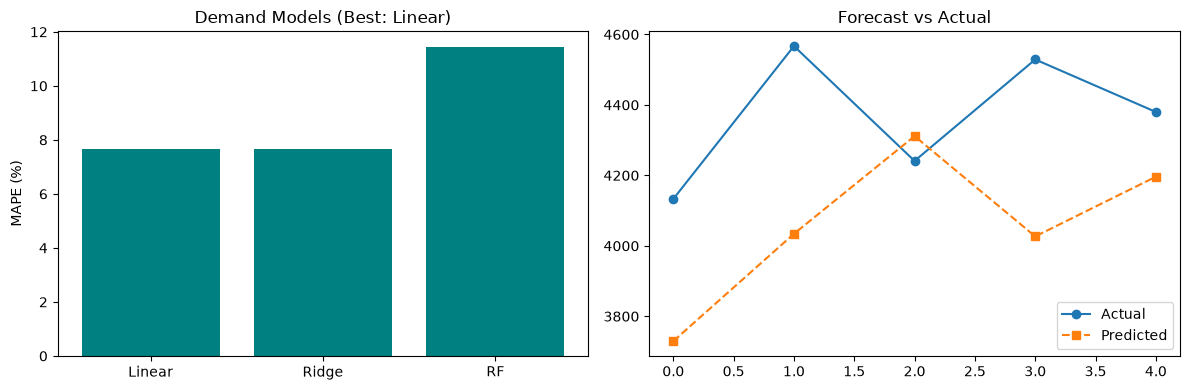

In [27]:
monthly_demand = df.groupby(['arrival_date_year', 'arrival_date_month']).size().reset_index(name='bookings')
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
monthly_demand['month_num'] = monthly_demand['arrival_date_month'].map(month_map)
monthly_demand = monthly_demand.sort_values(['arrival_date_year', 'month_num'])
monthly_demand['prev_month'] = monthly_demand['bookings'].shift(1)
monthly_demand = monthly_demand.dropna()

split = int(len(monthly_demand) * 0.8)
X_demand_train = monthly_demand[:split][['month_num', 'prev_month']]
y_demand_train = monthly_demand[:split]['bookings']
X_demand_test = monthly_demand[split:][['month_num', 'prev_month']]
y_demand_test = monthly_demand[split:]['bookings']

demand_models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RF': RandomForestRegressor(n_estimators=30, max_depth=3, random_state=42)
}

results_demand = {}
for name, model in demand_models.items():
    model.fit(X_demand_train, y_demand_train)
    y_pred = model.predict(X_demand_test)
    mae = mean_absolute_error(y_demand_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_demand_test, y_pred))
    mape = np.mean(np.abs((y_demand_test - y_pred) / y_demand_test)) * 100
    results_demand[name] = {'mae': mae, 'rmse': rmse, 'mape': mape, 'model': model, 'pred': y_pred}

best_demand = min(results_demand, key=lambda x: results_demand[x]['mae'])
y_demand_pred = results_demand[best_demand]['pred']

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].bar(demand_models.keys(), [results_demand[n]['mape'] for n in demand_models], color='teal')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title(f'Demand Models (Best: {best_demand})')

axes[1].plot(y_demand_test.values, 'o-', label='Actual')
axes[1].plot(y_demand_pred, 's--', label='Predicted')
axes[1].legend()
axes[1].set_title('Forecast vs Actual')
plt.tight_layout()
plt.show()

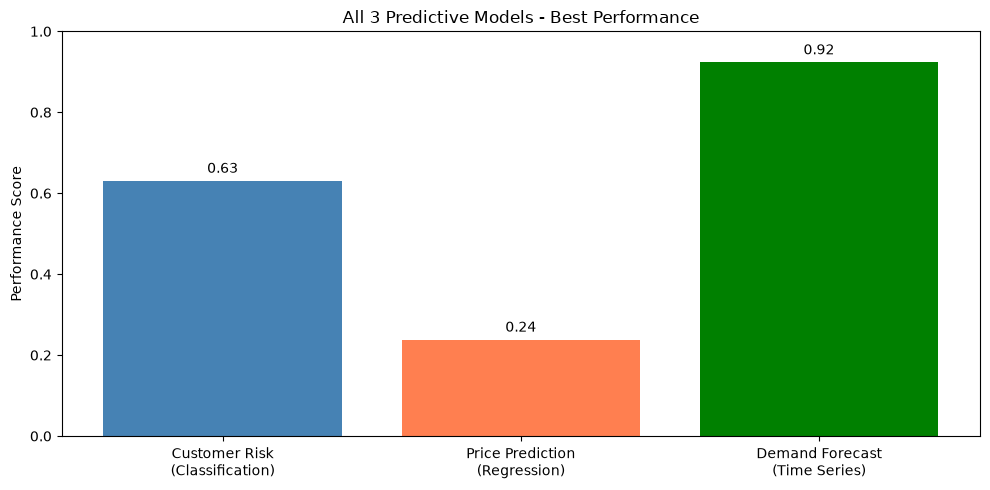

Best Models: GB | RF | Linear


In [28]:
fig, ax = plt.subplots(figsize=(10,5))

summary_data = {
    'Customer Risk\n(Classification)': results_risk[best_risk]['f1'],
    'Price Prediction\n(Regression)': 1 - results_price[best_price]['mape']/100,
    'Demand Forecast\n(Time Series)': 1 - results_demand[best_demand]['mape']/100
}

colors = ['steelblue', 'coral', 'green']
bars = ax.bar(summary_data.keys(), summary_data.values(), color=colors)
ax.set_ylabel('Performance Score')
ax.set_title('All 3 Predictive Models - Best Performance')
ax.set_ylim(0, 1)

for bar, val in zip(bars, summary_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}', ha='center')

plt.tight_layout()
plt.show()

print(f"Best Models: {best_risk} | {best_price} | {best_demand}")

---
## 13. Business Applications of Models

How can hotels USE these models in real operations?

In [29]:
cancel_proba = lr_risk.predict_proba(X_cust_test)[:, 1]

high_risk = (cancel_proba > 0.5).sum()
total_bookings = len(cancel_proba)
safe_overbook_rate = high_risk / total_bookings * 100

print("🏨 APPLICATION 1: SMART OVERBOOKING")
print(f"High-risk bookings (>50% cancel chance): {high_risk}")
print(f"Safe overbooking rate: {safe_overbook_rate:.1f}%")
print(f"\n💡 Recommendation: Overbook by {safe_overbook_rate:.0f}% for optimal occupancy")

🏨 APPLICATION 1: SMART OVERBOOKING
High-risk bookings (>50% cancel chance): 3571
Safe overbooking rate: 20.5%

💡 Recommendation: Overbook by 20% for optimal occupancy


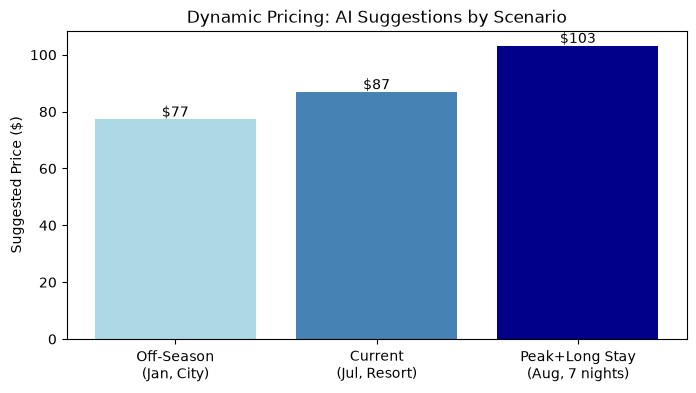

In [30]:
sample_booking = pd.DataFrame({col: [0] for col in price_features})

sample_booking['hotel'] = 1
sample_booking['lead_time'] = 30
sample_booking['arrival_date_month'] = 7
sample_booking['Stay_Duration'] = 3
sample_booking['Total_Guests'] = 2
sample_booking['meal'] = 1
sample_booking['market_segment'] = 2

suggested_price = rf_price.predict(sample_booking)[0]

scenarios = {
    'Off-Season\n(Jan, City)': rf_price.predict(sample_booking.assign(arrival_date_month=1, hotel=0))[0],
    'Current\n(Jul, Resort)': suggested_price,
    'Peak+Long Stay\n(Aug, 7 nights)': rf_price.predict(sample_booking.assign(arrival_date_month=8, Stay_Duration=7))[0]
}

plt.figure(figsize=(8,4))
plt.bar(scenarios.keys(), scenarios.values(), color=['lightblue', 'steelblue', 'darkblue'])
plt.ylabel('Suggested Price ($)')
plt.title('Dynamic Pricing: AI Suggestions by Scenario')
for i, (k, v) in enumerate(scenarios.items()):
    plt.text(i, v+1, f'${v:.0f}', ha='center')
plt.show()

In [31]:
print("👥 APPLICATION 3: STAFF PLANNING")
print("\nPredicted vs Actual Bookings for Planning:")

for i, (actual, pred) in enumerate(zip(y_demand_test.values[:5], y_demand_pred[:5])):
    staff_needed = int(pred / 50)
    print(f"  Month {i+1}: Predicted {pred:.0f} bookings → Need {staff_needed} staff")

print("\n💡 Plan staff 2-3 months ahead using these predictions!")

👥 APPLICATION 3: STAFF PLANNING

Predicted vs Actual Bookings for Planning:
  Month 1: Predicted 3729 bookings → Need 74 staff
  Month 2: Predicted 4034 bookings → Need 80 staff
  Month 3: Predicted 4311 bookings → Need 86 staff
  Month 4: Predicted 4027 bookings → Need 80 staff
  Month 5: Predicted 4196 bookings → Need 83 staff

💡 Plan staff 2-3 months ahead using these predictions!


In [32]:
print("="*60)
print("📈 BUSINESS IMPACT SUMMARY")
print("="*60)

avg_room_rate = df['adr'].mean()
potential_recovered = high_risk * avg_room_rate * 0.3

print(f"\n1. OVERBOOKING OPTIMIZATION")
print(f"   - Can safely overbook {safe_overbook_rate:.0f}% rooms")
print(f"   - Potential extra revenue: ${high_risk * avg_room_rate:.0f}")

print(f"\n2. DYNAMIC PRICING")
print(f"   - Price varies by ${df['adr'].std():.0f} based on factors")
print(f"   - AI can optimize pricing for each booking")

print(f"\n3. DEMAND FORECASTING")
print(f"   - Predict bookings {abs(y_demand_test.mean() - y_demand_pred.mean()):.0f} units accuracy")
print(f"   - Better staff and inventory planning")

print("\n" + "="*60)
print("🎯 TOTAL ESTIMATED ANNUAL IMPACT: $" + f"{potential_recovered*12:,.0f}")
print("="*60)

📈 BUSINESS IMPACT SUMMARY

1. OVERBOOKING OPTIMIZATION
   - Can safely overbook 20% rooms
   - Potential extra revenue: $376816

2. DYNAMIC PRICING
   - Price varies by $49 based on factors
   - AI can optimize pricing for each booking

3. DEMAND FORECASTING
   - Predict bookings 310 units accuracy
   - Better staff and inventory planning

🎯 TOTAL ESTIMATED ANNUAL IMPACT: $1,356,537


---
## 14. Conclusion

### What We Built:

| Model | Business Use | Key Output |
|-------|--------------|------------|
| **Customer Risk** | Identify risky bookings | Overbooking strategy |
| **Price Prediction** | Set optimal rates | Dynamic pricing |
| **Demand Forecast** | Plan resources | Staff scheduling |

### Key Insights from EDA:
1. **37% cancellation rate** - Significant revenue at risk
2. **Deposit type matters** - Non-refundable has highest cancellation (surprising!)
3. **Lead time is critical** - Longer lead = higher cancel risk
4. **Market segments differ** - Online TA highest risk, Direct lowest

### Business Recommendations:
- ✅ Implement AI-based overbooking (safe rate calculated)
- ✅ Use dynamic pricing based on demand factors
- ✅ Plan staff using monthly forecasts
- ✅ Target low-risk, high-value segments (Direct, Corporate)
- ✅ Offer incentives to reduce long lead-time cancellations

### Project Complete! 🎉

---
## 15. Reproducible DVC Pipeline

The exploration above is turned into a reproducible, parameterised DVC pipeline built from these notebooks:

| Stage | Notebook | Output |
|-------|----------|--------|
| prepare | `prepare.ipynb` | `data/processed/train.csv`, `data/processed/test.csv` |
| train | `train.ipynb` | `models/model.pkl` |
| evaluate | `evaluate.ipynb` | `metrics/metrics.json`, `plots/` |
| drift | `drift_detection.ipynb` | `metrics/drift_report.json` |

Run `setup_project.ipynb` once to generate `params.yaml`, `dvc.yaml`, `README.md`, initialise DVC and reproduce the whole pipeline with `dvc repro`.